# HydroSense-Kenya
## Level 1: Scientific Problem Framing and Python Foundation
**ICS 2207 Scientific Computing | Capstone Project**

---

## 1. Problem Statement

### Background and Context

Agriculture is the backbone of Kenya's economy, employing over 40% of the total population and contributing approximately 33% of GDP. Yet smallholder farmers — who account for the majority of food production — face a growing threat that is both invisible and increasingly severe: **water mismanagement under a changing climate**.

In semi-arid and sub-humid zones of Kenya — regions such as Machakos, Kitui, Makueni, and parts of Rift Valley — rainfall is irregular, often arriving in short intense bursts separated by prolonged dry spells. Traditional flood irrigation, which many farms still rely on, wastes enormous volumes of water and leaves crops vulnerable to moisture stress during dry intervals. At the same time, over-irrigation causes soil degradation, waterlogging, and unnecessary pump-energy expenditure.

University demonstration farms and agricultural innovation hubs are increasingly called upon to model sustainable farming practices for surrounding smallholder communities. However, most lack the computational tools to translate the sensor data they collect — rainfall gauges, soil-moisture probes, tank-level monitors, pump meters — into concrete, science-backed irrigation decisions.

### The Central Scientific Question

> *Given daily weather observations and soil-sensor readings, how can we mathematically model the soil-water balance, detect water-stress risk, simulate future soil-moisture trajectories under uncertain rainfall, and recommend an efficient irrigation schedule that minimises water use without exposing crops to moisture stress?*

### What HydroSense-Kenya Will Do

HydroSense-Kenya is a Python-based scientific computing system that will:

1. **Ingest and clean** daily weather data (rainfall, temperature, humidity, wind, solar index) and soil-sensor data (moisture, tank level, pump flow) from a three-zone demonstration farm.
2. **Compute evapotranspiration (ET)** — the daily rate at which water is lost from soil to atmosphere through plant transpiration and direct evaporation — using an empirical formula calibrated for East African conditions.
3. **Simulate the discrete soil-water balance** day by day, tracking how rainfall, irrigation, ET, and drainage interact to raise or lower soil moisture in each crop zone.
4. **Detect water stress** by comparing simulated soil moisture against crop-specific minimum thresholds (tomato: 22%, kale: 24%, maize: 20%).
5. **Run Monte Carlo simulations** to quantify irrigation risk under uncertain future rainfall, producing probabilistic forecasts of water shortage and over-irrigation.
6. **Optimise irrigation scheduling** to find the minimum daily irrigation volume that keeps each zone above its stress threshold while conserving tank water and reducing pump-energy demand.

### Why This Matters in an African Context

Climate projections for Eastern Africa (IPCC AR6, 2021) indicate increased rainfall variability and more frequent extreme events — both droughts and flash floods. A farm system that cannot adapt its irrigation decisions to this variability risks either crop failure (under-irrigation) or resource waste (over-irrigation). HydroSense-Kenya provides a replicable, open-source, data-driven framework that a university farm manager, extension officer, or trained smallholder can operate using low-cost sensors and a laptop.

### Assumptions and Limitations of the Initial Model

| Assumption | Justification | Limitation |
|---|---|---|
| ET formula is empirical and simplified | Suitable for teaching; avoids requiring full agronomic instrumentation | Less accurate than Penman-Monteith for specific crops |
| Soil is treated as a single layer per zone | Reduces complexity for simulation | Ignores vertical moisture gradients |
| Drainage is proportional to excess above field capacity | First-order approximation of soil drainage physics | Does not model preferential flow or soil texture |
| Rainfall is uniformly distributed across zones | Farm is small (~400 m² total); spatial variation is minimal | Would not hold for larger farms |
| Pump flow is assumed constant within a day | Simplifies the water balance calculation | Ignores variable pumping rates during the day |
| Dataset covers March 2026 only (30 days) | Representative short rains period for many Kenyan regions | Insufficient for inter-annual climate analysis |

---

## 2. Import Libraries

In [7]:
import os
print("Current working directory:", os.getcwd())
print("\nFiles here:", os.listdir(os.getcwd()))

Current working directory: c:\Users\ADMIN\Downloads

Files here: ['06acdf9e-7a3f-4753-a119-8028df984ab3.png', '1-bmp-sample-2.bmp', '1. Intro Data Structures and Algorithms.pdf', '10.2305_IUCN.UK.2015-4.RLTS.T22823A14871490.en.pdf', '2. Searching, Sorting and Linked Lists.pdf', '2026 free planner.pdf.zip', '2026-04-23 09.28.51.pdf', '2bubble.jpeg', '3. Double Linked and Circular  Lists 28.10.24.pdf', '4. Queues & Stacks 28.10.24.pdf', '4d85eb60-91e9-41b3-b158-c677222db63b.ics', '5. Trees.pdf', '6. Graphs.pdf', '7z2501-x64 (1).exe', '7z2501-x64 (2).exe', '7z2501-x64.exe', '7[1].pdf', '89-professional-foundations-certificate-patricia-wachira (1).png', '89-professional-foundations-certificate-patricia-wachira.png', '8[1].pdf', '973d576b-b33e-4fad-bae9-fdd991c5628d.tmp', 'Additional questions.docx', 'admission.pdf', 'ai_studio_code.ts', 'all rooms.jpg', 'americano.jpg', 'android-studio-2024.1.1.12-windows (1).exe', 'android-studio-2024.1.1.12-windows.exe', 'android-studio-2024.2.1.10-windo

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import os
os.chdir(os.path.dirname(os.path.abspath("__file__")))

# Set consistent plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully.
NumPy version: 2.4.4
Pandas version: 3.0.2


## 3. Load Datasets and Inspect Structure

In [9]:
# Load all three datasets
import os
BASE = r"C:\Users\ADMIN\Desktop\hydrosense_kenya"
DATA_RAW = os.path.join(BASE, "data", "raw")

weather = pd.read_csv(os.path.join(DATA_RAW, "weather_daily.csv"), na_values=["NA", ""])
soil    = pd.read_csv(os.path.join(DATA_RAW, "soil_sensor_data.csv"), na_values=["NA", ""])
params  = pd.read_csv(os.path.join(DATA_RAW, "crop_zone_parameters.csv"), na_values=["NA", ""])

# Parse date columns
weather['date'] = pd.to_datetime(weather['date'])
soil['timestamp'] = pd.to_datetime(soil['timestamp'])

print("=" * 50)
print("WEATHER DATASET")
print("=" * 50)
print(weather.info())
print("\nFirst 5 rows:")
print(weather.head())

WEATHER DATASET
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            30 non-null     datetime64[us]
 1   rainfall_mm     29 non-null     float64       
 2   temperature_c   30 non-null     float64       
 3   humidity_pct    29 non-null     float64       
 4   wind_speed_mps  30 non-null     float64       
 5   solar_index     30 non-null     float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 1.5 KB
None

First 5 rows:
        date  rainfall_mm  temperature_c  humidity_pct  wind_speed_mps  \
0 2026-03-01          3.2           23.8          69.7            2.28   
1 2026-03-02          2.2           25.9          62.0            1.62   
2 2026-03-03          3.0           26.8          64.4            2.11   
3 2026-03-04          1.6           27.0          64.6            2.09   
4 2026-03-05         23.7   

In [10]:
print("=" * 50)
print("SOIL SENSOR DATASET")
print("=" * 50)
print(soil.info())
print("\nFirst 6 rows (2 days × 3 zones):")
print(soil.head(6))

SOIL SENSOR DATASET
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          90 non-null     datetime64[us]
 1   zone_id            90 non-null     str           
 2   soil_moisture_pct  89 non-null     float64       
 3   tank_level_liters  90 non-null     int64         
 4   pump_flow_lpm      90 non-null     float64       
 5   pump_power_watts   90 non-null     int64         
 6   sensor_status      90 non-null     str           
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 5.1 KB
None

First 6 rows (2 days × 3 zones):
            timestamp zone_id  soil_moisture_pct  tank_level_liters  \
0 2026-03-01 12:00:00  Zone_A               33.2               4829   
1 2026-03-01 12:00:00  Zone_B               34.7               4728   
2 2026-03-01 12:00:00  Zone_C               28.2               45

In [11]:
print("=" * 50)
print("CROP ZONE PARAMETERS")
print("=" * 50)
print(params.info())
print("\nAll rows:")
print(params)

CROP ZONE PARAMETERS
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   zone_id               3 non-null      str    
 1   crop_type             3 non-null      str    
 2   area_m2               3 non-null      int64  
 3   min_moisture_pct      3 non-null      int64  
 4   target_moisture_pct   3 non-null      int64  
 5   field_capacity_pct    3 non-null      int64  
 6   drainage_coefficient  3 non-null      float64
dtypes: float64(1), int64(4), str(2)
memory usage: 300.0 bytes
None

All rows:
  zone_id crop_type  area_m2  min_moisture_pct  target_moisture_pct  \
0  Zone_A    tomato      120                22                   33   
1  Zone_B      kale       90                24                   35   
2  Zone_C     maize      180                20                   31   

   field_capacity_pct  drainage_coefficient  
0                  41

## 4. Data Dictionary

### 4.1 weather_daily.csv

In [12]:
weather_dict = pd.DataFrame({
    'Variable': ['date', 'rainfall_mm', 'temperature_c', 'humidity_pct', 'wind_speed_mps', 'solar_index'],
    'Description': [
        'Calendar date of the observation',
        'Total daily rainfall measured at the farm rain gauge',
        'Mean daily air temperature at 2 m above ground',
        'Mean daily relative humidity as a percentage',
        'Mean daily wind speed measured at 2 m above ground',
        'Dimensionless index of solar radiation intensity (0 = no sun, 1 = maximum)'
    ],
    'Units': ['YYYY-MM-DD', 'mm', '°C', '%', 'm/s', 'dimensionless (0–1)'],
    'Data Type': ['datetime', 'float', 'float', 'float', 'float', 'float'],
    'Expected Range': ['2026-03-01 to 2026-03-30', '0–80 mm', '15–35 °C', '30–100 %', '0–10 m/s', '0.0–1.0'],
    'Missing Values': ['None', '1 (Mar 08)', 'None', '1 (Mar 21)', 'None', 'None'],
    'Notes': [
        'Primary time key',
        'Outlier: 85 mm on Mar 26 — likely extreme rainfall event; needs review',
        'Outlier: 45.8°C on Mar 14 — physiologically implausible for Kenya; likely sensor fault',
        'Moderate variability expected in East African short-rains period',
        'Low values typical for inland Kenyan farms',
        'Used directly in ET formula'
    ]
})
print("Weather Data Dictionary")
print(weather_dict.to_string(index=False))

Weather Data Dictionary
      Variable                                                                Description               Units Data Type           Expected Range Missing Values                                                                                  Notes
          date                                           Calendar date of the observation          YYYY-MM-DD  datetime 2026-03-01 to 2026-03-30           None                                                                       Primary time key
   rainfall_mm                       Total daily rainfall measured at the farm rain gauge                  mm     float                  0–80 mm     1 (Mar 08)                 Outlier: 85 mm on Mar 26 — likely extreme rainfall event; needs review
 temperature_c                             Mean daily air temperature at 2 m above ground                  °C     float                 15–35 °C           None Outlier: 45.8°C on Mar 14 — physiologically implausible for Kenya; likely s

In [13]:
soil_dict = pd.DataFrame({
    'Variable': ['timestamp', 'zone_id', 'soil_moisture_pct', 'tank_level_liters',
                 'pump_flow_lpm', 'pump_power_watts', 'sensor_status'],
    'Description': [
        'Date and time of sensor reading (daily at noon)',
        'Farm zone identifier',
        'Volumetric soil moisture content measured by sensor',
        'Water volume remaining in the storage tank for this zone',
        'Flow rate of the irrigation pump at time of reading',
        'Electrical power consumption of the pump at time of reading',
        'Sensor self-diagnostic flag'
    ],
    'Units': ['YYYY-MM-DD HH:MM', 'Zone_A / Zone_B / Zone_C', '%', 'litres', 'L/min', 'watts', 'OK / CHECK'],
    'Data Type': ['datetime', 'string/categorical', 'float', 'integer', 'float', 'integer', 'string'],
    'Expected Range': ['-', '-', '20–45 %', '3000–5000 L', '15–30 L/min', '380–530 W', 'OK'],
    'Notes': [
        'One reading per zone per day',
        'Three zones: tomato (A), kale (B), maize (C)',
        'Missing: 1 value (Zone_B, Mar 06); Outlier: 8.5% Zone_B Mar 25 — critically low',
        'Outlier: 9900 L on Zone_C Mar 14 — exceeds plausible tank capacity',
        'Zero flow on Zone_B Mar 21 correlates with CHECK sensor status — possible pump fault',
        'Higher power generally corresponds to higher flow rates',
        'CHECK flag on Zone_B Mar 21 — indicates sensor anomaly requiring investigation'
    ]
})
print("Soil Sensor Data Dictionary")
print(soil_dict.to_string(index=False))

Soil Sensor Data Dictionary
         Variable                                                 Description                    Units          Data Type Expected Range                                                                                Notes
        timestamp             Date and time of sensor reading (daily at noon)         YYYY-MM-DD HH:MM           datetime              -                                                         One reading per zone per day
          zone_id                                        Farm zone identifier Zone_A / Zone_B / Zone_C string/categorical              -                                         Three zones: tomato (A), kale (B), maize (C)
soil_moisture_pct         Volumetric soil moisture content measured by sensor                        %              float        20–45 %      Missing: 1 value (Zone_B, Mar 06); Outlier: 8.5% Zone_B Mar 25 — critically low
tank_level_liters    Water volume remaining in the storage tank for this zone       

In [14]:
params_dict = pd.DataFrame({
    'Variable': ['zone_id', 'crop_type', 'area_m2', 'min_moisture_pct',
                 'target_moisture_pct', 'field_capacity_pct', 'drainage_coefficient'],
    'Description': [
        'Farm zone identifier (matches soil sensor data)',
        'Crop grown in this zone',
        'Physical area of the crop zone',
        'Minimum acceptable soil moisture — below this, crop experiences water stress',
        'Desired soil moisture level for optimal crop growth',
        'Maximum soil moisture the soil can hold before drainage occurs',
        'Fraction of excess water above field capacity that drains away per day'
    ],
    'Units': ['-', '-', 'm²', '%', '%', '%', 'fraction per day (0–1)'],
    'Values': ['Zone_A / Zone_B / Zone_C', 'tomato / kale / maize',
               '120 / 90 / 180', '22 / 24 / 20', '33 / 35 / 31',
               '41 / 43 / 40', '0.18 / 0.15 / 0.22']
})
print("Crop Zone Parameters Dictionary")
print(params_dict.to_string(index=False))

Crop Zone Parameters Dictionary
            Variable                                                                  Description                  Units                   Values
             zone_id                              Farm zone identifier (matches soil sensor data)                      - Zone_A / Zone_B / Zone_C
           crop_type                                                      Crop grown in this zone                      -    tomato / kale / maize
             area_m2                                               Physical area of the crop zone                     m²           120 / 90 / 180
    min_moisture_pct Minimum acceptable soil moisture — below this, crop experiences water stress                      %             22 / 24 / 20
 target_moisture_pct                          Desired soil moisture level for optimal crop growth                      %             33 / 35 / 31
  field_capacity_pct               Maximum soil moisture the soil can hold before drainage o

## 5. Core Scientific Functions

### 5.1 Evapotranspiration Function

The simplified empirical ET formula used in this project is:

$$ET = \max(0,\; 0.12T + 0.35W + 2.4 \cdot Solar - 0.025H)$$

Where:
- $T$ = temperature (°C)
- $W$ = wind speed (m/s)
- $Solar$ = solar index (0–1)
- $H$ = relative humidity (%)

In [15]:
def compute_et(temperature_c, wind_speed_mps, solar_index, humidity_pct):
    """
    Compute daily evapotranspiration (ET) using a simplified empirical formula.

    The formula is calibrated for teaching purposes and approximates crop water
    demand based on four atmospheric variables. It is not a substitute for
    the full Penman-Monteith equation used in professional agronomy.

    Parameters
    ----------
    temperature_c   : float or array-like — air temperature in degrees Celsius
    wind_speed_mps  : float or array-like — wind speed in metres per second
    solar_index     : float or array-like — dimensionless solar intensity index (0–1)
    humidity_pct    : float or array-like — relative humidity in percent

    Returns
    -------
    float or array-like — estimated ET in mm/day (always >= 0)

    Examples
    --------
    >>> compute_et(25.0, 2.0, 0.75, 65.0)
    3.975
    """
    et = 0.12 * temperature_c + 0.35 * wind_speed_mps + 2.4 * solar_index - 0.025 * humidity_pct
    return max(0.0, et)


# Quick verification
et_test = compute_et(25.0, 2.0, 0.75, 65.0)
print(f"ET test (T=25°C, W=2 m/s, Solar=0.75, H=65%): {et_test:.4f} mm/day")
print(f"Expected: {0.12*25 + 0.35*2 + 2.4*0.75 - 0.025*65:.4f} mm/day")

# Edge case: ET should never be negative
et_cold = compute_et(5.0, 0.1, 0.05, 95.0)
print(f"\nET edge case (cold/humid/still/overcast): {et_cold:.4f} mm/day (should be 0.0)")

ET test (T=25°C, W=2 m/s, Solar=0.75, H=65%): 3.8750 mm/day
Expected: 3.8750 mm/day

ET edge case (cold/humid/still/overcast): 0.0000 mm/day (should be 0.0)


### 5.2 Water Balance Function

The discrete daily water balance equation:

$$S_{t+1} = S_t + R_t + I_t - ET_t - D_t$$

Where drainage: $D_t = \max(0,\; (S_t - FC) \times d)$ and $FC$ = field capacity, $d$ = drainage coefficient.

In [16]:
def compute_water_balance(soil_moisture, rainfall_mm, irrigation_mm,
                          et_mm, field_capacity_pct, drainage_coeff):
    """
    Compute the next day's soil moisture using the discrete water balance equation.

    Equation:
        S_{t+1} = S_t + R_t + I_t - ET_t - D_t

    Where drainage D_t = max(0, (S_t - field_capacity) * drainage_coeff)

    Parameters
    ----------
    soil_moisture    : float — current soil moisture (% volumetric)
    rainfall_mm      : float — daily rainfall in mm (converted to % using a scaling factor)
    irrigation_mm    : float — irrigation applied in mm
    et_mm            : float — evapotranspiration estimate in mm
    field_capacity_pct : float — maximum soil moisture before drainage (%)
    drainage_coeff   : float — fraction of excess water that drains per day

    Returns
    -------
    dict with keys:
        'new_moisture'  : float — updated soil moisture (%)
        'drainage'      : float — drainage loss (% units)
        'water_deficit' : float — shortfall below field capacity (positive = deficit)

    Notes
    -----
    Rainfall and ET are converted from mm to percentage-point units using
    a simplified scaling factor of 0.1 (1 mm rainfall ≈ 0.1 % soil moisture
    change in a shallow root zone). This is a teaching simplification.
    """
    # Convert mm to approximate soil-moisture percentage units
    SCALE = 0.1  # mm → % conversion factor (simplified)
    rain_pct  = rainfall_mm  * SCALE
    irrig_pct = irrigation_mm * SCALE
    et_pct    = et_mm * SCALE

    # Drainage only occurs when current moisture exceeds field capacity
    excess   = max(0.0, soil_moisture - field_capacity_pct)
    drainage = excess * drainage_coeff

    # Update soil moisture
    new_moisture = soil_moisture + rain_pct + irrig_pct - et_pct - drainage

    # Soil moisture cannot be negative
    new_moisture = max(0.0, new_moisture)

    water_deficit = max(0.0, field_capacity_pct - new_moisture)

    return {
        'new_moisture' : round(new_moisture, 4),
        'drainage'     : round(drainage, 4),
        'water_deficit': round(water_deficit, 4)
    }


# Demonstration
result = compute_water_balance(
    soil_moisture      = 30.0,   # current moisture 30%
    rainfall_mm        = 5.0,    # 5 mm rain today
    irrigation_mm      = 0.0,    # no irrigation
    et_mm              = 4.0,    # 4 mm ET
    field_capacity_pct = 41.0,   # Zone_A field capacity
    drainage_coeff     = 0.18    # Zone_A drainage coefficient
)
print("Water Balance Demonstration")
print(f"  Starting moisture : 30.0 %")
print(f"  Rainfall          : 5.0 mm (+{5.0*0.1:.1f}%)")
print(f"  ET                : 4.0 mm (-{4.0*0.1:.1f}%)")
print(f"  Drainage          : {result['drainage']:.4f} %")
print(f"  New moisture      : {result['new_moisture']:.4f} %")
print(f"  Water deficit     : {result['water_deficit']:.4f} %")

Water Balance Demonstration
  Starting moisture : 30.0 %
  Rainfall          : 5.0 mm (+0.5%)
  ET                : 4.0 mm (-0.4%)
  Drainage          : 0.0000 %
  New moisture      : 30.1000 %
  Water deficit     : 10.9000 %


### 5.3 Stress Detection Function

In [17]:
def detect_water_stress(soil_moisture, min_moisture_pct, zone_id, date=None):
    """
    Determine whether a crop zone is experiencing water stress.

    Water stress occurs when soil moisture falls below the crop-specific
    minimum threshold. Stress inhibits photosynthesis, reduces yield,
    and can cause irreversible cell damage in severe cases.

    Parameters
    ----------
    soil_moisture    : float — current soil moisture (%)
    min_moisture_pct : float — crop minimum moisture threshold (%)
    zone_id          : str   — zone identifier for reporting
    date             : optional — date for reporting

    Returns
    -------
    dict with keys:
        'stressed'   : bool   — True if moisture is below threshold
        'deficit'    : float  — how far below threshold (0 if not stressed)
        'severity'   : str    — 'None', 'Mild', 'Moderate', or 'Severe'
        'message'    : str    — human-readable status message
    """
    deficit = max(0.0, min_moisture_pct - soil_moisture)
    stressed = deficit > 0

    if deficit == 0:
        severity = 'None'
    elif deficit < 2:
        severity = 'Mild'
    elif deficit < 5:
        severity = 'Moderate'
    else:
        severity = 'Severe'

    date_str = f" on {date}" if date else ""
    if stressed:
        message = (f"[{severity.upper()} STRESS] {zone_id}{date_str}: "
                   f"moisture {soil_moisture:.1f}% is {deficit:.1f}% below minimum ({min_moisture_pct}%)")
    else:
        message = (f"[OK] {zone_id}{date_str}: moisture {soil_moisture:.1f}% "
                   f"is {abs(deficit):.1f}% above minimum ({min_moisture_pct}%)")

    return {'stressed': stressed, 'deficit': round(deficit, 2),
            'severity': severity, 'message': message}


# Test all three zones against a simulated dry day
test_cases = [
    ('Zone_A (Tomato)', 20.5, 22),   # below minimum
    ('Zone_B (Kale)',   25.0, 24),   # just above minimum
    ('Zone_C (Maize)',  16.0, 20),   # severely below minimum
]

print("Water Stress Detection Test Cases\n")
for zone, moisture, min_m in test_cases:
    result = detect_water_stress(moisture, min_m, zone, date='2026-03-17')
    print(result['message'])
    print(f"  severity={result['severity']}, deficit={result['deficit']}%\n")

Water Stress Detection Test Cases

[MILD STRESS] Zone_A (Tomato) on 2026-03-17: moisture 20.5% is 1.5% below minimum (22%)
  severity=Mild, deficit=1.5%

[OK] Zone_B (Kale) on 2026-03-17: moisture 25.0% is 0.0% above minimum (24%)
  severity=None, deficit=0.0%

[MODERATE STRESS] Zone_C (Maize) on 2026-03-17: moisture 16.0% is 4.0% below minimum (20%)
  severity=Moderate, deficit=4.0%



## 6. Basic Scientific Plot: Rainfall Over Time

This plot visualises the daily rainfall pattern across the 30-day observation period. It helps identify dry spells, moderate rain events, and the single extreme rainfall event on 26 March.

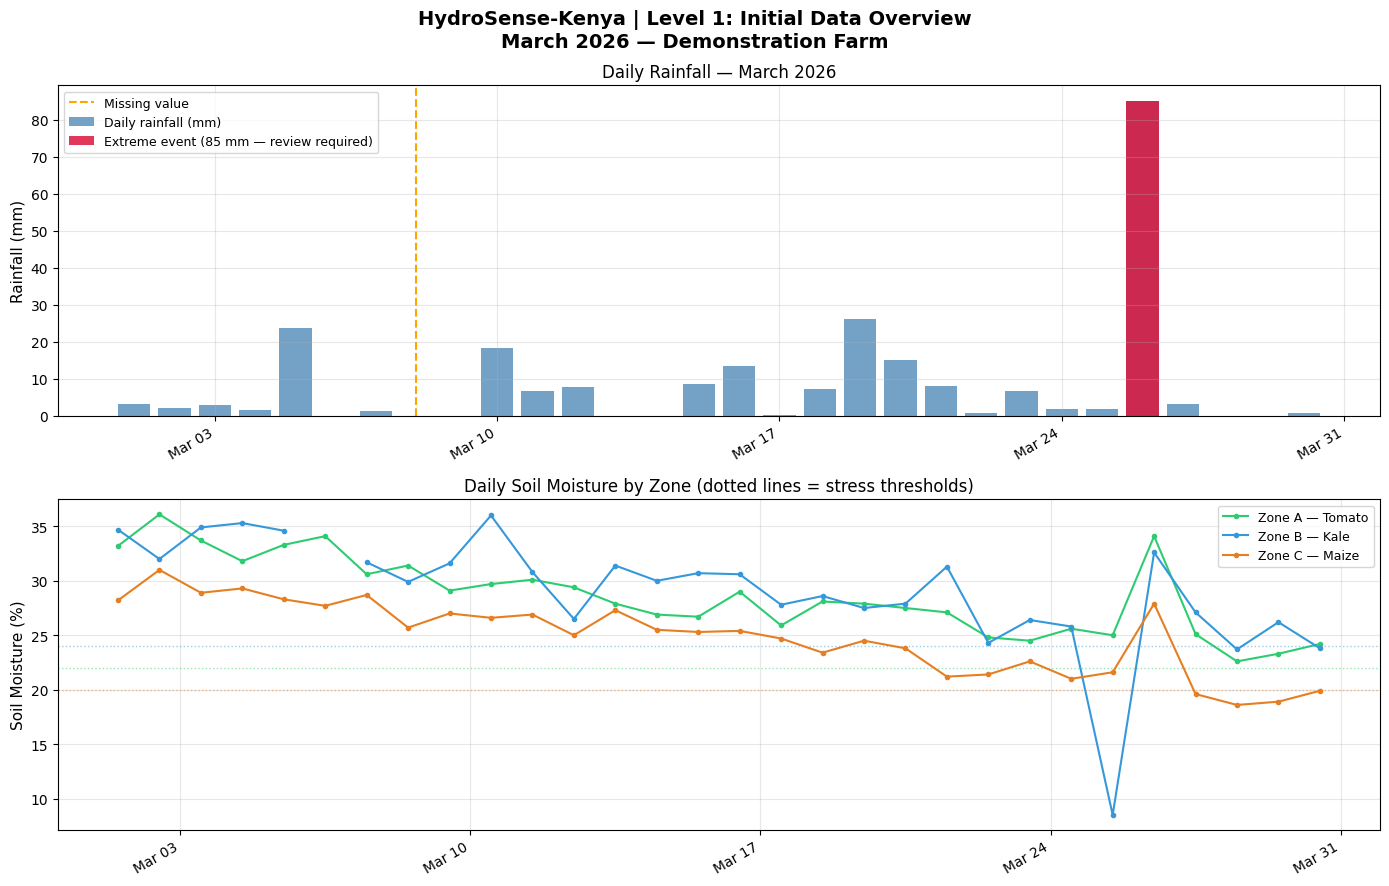

Plot saved to data/processed/level1_overview_plot.png


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('HydroSense-Kenya | Level 1: Initial Data Overview\nMarch 2026 — Demonstration Farm',
             fontsize=14, fontweight='bold', y=0.98)

# ── Plot 1: Daily Rainfall ────────────────────────────────────────────────
ax1 = axes[0]
rainfall_clean = weather['rainfall_mm'].fillna(0)  # fill the one NA for plotting only
bars = ax1.bar(weather['date'], rainfall_clean, color='steelblue', alpha=0.75,
               label='Daily rainfall (mm)', width=0.8)

# Highlight the outlier
outlier_date = weather.loc[weather['rainfall_mm'] == 85.0, 'date']
if not outlier_date.empty:
    ax1.bar(outlier_date, [85.0], color='crimson', alpha=0.85,
            label='Extreme event (85 mm — review required)', width=0.8)

# Mark the missing value
missing_date = weather.loc[weather['rainfall_mm'].isna(), 'date']
for md in missing_date:
    ax1.axvline(md, color='orange', linestyle='--', linewidth=1.5, label='Missing value')

ax1.set_ylabel('Rainfall (mm)', fontsize=11)
ax1.set_title('Daily Rainfall — March 2026', fontsize=12)
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Plot 2: Soil Moisture by Zone ─────────────────────────────────────────
ax2 = axes[1]
zone_colors = {'Zone_A': '#2ecc71', 'Zone_B': '#3498db', 'Zone_C': '#e67e22'}
zone_labels = {'Zone_A': 'Zone A — Tomato', 'Zone_B': 'Zone B — Kale', 'Zone_C': 'Zone C — Maize'}
zone_mins   = {'Zone_A': 22, 'Zone_B': 24, 'Zone_C': 20}

for zone in ['Zone_A', 'Zone_B', 'Zone_C']:
    zone_data = soil[soil['zone_id'] == zone].copy()
    zone_data = zone_data.sort_values('timestamp')
    ax2.plot(zone_data['timestamp'], zone_data['soil_moisture_pct'],
             color=zone_colors[zone], marker='o', markersize=3,
             linewidth=1.5, label=zone_labels[zone])
    # Draw minimum threshold line
    ax2.axhline(zone_mins[zone], color=zone_colors[zone], linestyle=':',
                alpha=0.5, linewidth=1)

ax2.set_ylabel('Soil Moisture (%)', fontsize=11)
ax2.set_title('Daily Soil Moisture by Zone (dotted lines = stress thresholds)', fontsize=12)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
os.makedirs("../data/processed", exist_ok=True)
plt.savefig('../data/processed/level1_overview_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/processed/level1_overview_plot.png")

### Plot Interpretation

**Rainfall panel**: The farm experienced mostly light rainfall (0–10 mm/day) during early and mid-March, with two heavier events on 19 March (26.3 mm) and 26 March (85 mm). The 85 mm event on 26 March is flagged as a potential outlier — it is approximately 3× the next highest daily rainfall and exceeds what most Kenyan short-rains events produce in a single day. This will require cleaning decision in Level 4 (retain with flag vs. impute vs. cap). The missing value on 8 March is marked; it will need imputation in Level 4.

**Soil moisture panel**: All three zones begin March above their stress thresholds but trend downward through mid-March as ET exceeds modest rainfall inputs. Zone C (Maize) consistently shows the lowest moisture, approaching its 20% threshold on several days in mid-to-late March. The visible moisture recovery on 26 March corresponds to the extreme rainfall event. The anomalously low 8.5% reading for Zone B on 25 March is not visible at this scale but will be a key data-cleaning target in Level 4.

## 7. Initial ET Computation Across the Dataset

In [22]:
# Apply ET function row-by-row (loop-based, as required for Level 1)
# Note: Level 2 will replace this with NumPy vectorization for comparison

et_values = []
for _, row in weather.iterrows():
    if pd.isna(row['humidity_pct']):
        # Use the monthly mean as a temporary stand-in for the missing humidity value
        humidity = weather['humidity_pct'].mean()
    else:
        humidity = row['humidity_pct']

    et = compute_et(
        temperature_c  = row['temperature_c'],
        wind_speed_mps = row['wind_speed_mps'],
        solar_index    = row['solar_index'],
        humidity_pct   = humidity
    )
    et_values.append(et)

weather['et_mm'] = et_values

print("Evapotranspiration Summary (mm/day)")
print(f"  Minimum  : {weather['et_mm'].min():.3f} mm/day")
print(f"  Maximum  : {weather['et_mm'].max():.3f} mm/day")
print(f"  Mean     : {weather['et_mm'].mean():.3f} mm/day")
print(f"  Total    : {weather['et_mm'].sum():.2f} mm over 30 days")
print(f"\nNote: Maximum ET on {weather.loc[weather['et_mm'].idxmax(), 'date'].date()} — "
      f"temperature was {weather.loc[weather['et_mm'].idxmax(), 'temperature_c']}°C")
print("This corresponds to the outlier temperature day (45.8°C) — further evidence of a sensor fault.")

Evapotranspiration Summary (mm/day)
  Minimum  : 2.647 mm/day
  Maximum  : 5.982 mm/day
  Mean     : 3.744 mm/day
  Total    : 112.32 mm over 30 days

Note: Maximum ET on 2026-03-14 — temperature was 45.8°C
This corresponds to the outlier temperature day (45.8°C) — further evidence of a sensor fault.


## 8. Level 1 Summary

### What was accomplished

| Task | Status |
|---|---|
| Problem statement (500–700 words) | ✅ Complete |
| Load and inspect all three datasets | ✅ Complete |
| Data dictionary for all variables | ✅ Complete |
| `compute_et()` function | ✅ Complete |
| `compute_water_balance()` function | ✅ Complete |
| `detect_water_stress()` function | ✅ Complete |
| Basic plots (rainfall + soil moisture) | ✅ Complete |
| Assumptions and limitations stated | ✅ Complete |

### Key observations to carry forward

1. **Data quality issues identified** (to be formally addressed in Level 4): temperature outlier (45.8°C, Mar 14), rainfall outlier (85 mm, Mar 26), tank-level outlier (9900 L, Zone C Mar 14), moisture outlier (8.5%, Zone B Mar 25), sensor CHECK flag (Zone B Mar 21), one missing rainfall value, one missing humidity value.
2. **Zone C (Maize)** is the most moisture-stressed zone and will likely require the highest relative irrigation allocation.
3. **The ET formula amplifies the temperature outlier** — producing an implausibly high ET on 14 March — confirming that raw data cannot be used directly in the model before cleaning.

### Next steps: Level 2
Level 2 will re-implement the ET computation using NumPy vectorization, compare performance against the loop-based approach above, and conduct a formal floating-point error and error-propagation analysis.